In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field, replace
from datetime import datetime, timedelta, timezone
from functools import lru_cache
from pathlib import Path
from typing import Any, Callable, Sequence
import itertools
import json
import logging

import joblib
import nico2_lib as n2l
from nico2_lib.predictors._scvi._scvi_pred import ScviPredictor
import numpy as np
import polars as pl
import scanpy as sc
import seaborn as sns
from anndata.typing import AnnData
from joblib import Memory
from numpy import number, str_
from numpy.typing import NDArray
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
from umap import UMAP


DATA_DIR = "./data"
CACHE_DIR = "./cache"
ARTIFACT_SUBDIR = "runs"
DEFAULT_SEED = 0
DEFAULT_N_SAMPLES = 2
DEFAULT_SAMPLE_LENGTH = 20
SCHEMA_VERSION = "2.0.0"
TIMESTAMP_FORMAT = "%Y%m%dT%H%M%SZ"

if not logging.getLogger().handlers:
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    )
logger = logging.getLogger(__name__)


NumericArray = NDArray[number]
StringArray = NDArray[str_]
LoaderFn = Callable[[str], tuple[AnnData, AnnData, str, str]]
PredictorFactory = Callable[..., n2l.pd.PredictorProtocol]
MetricFn = Callable[[NumericArray, NumericArray], float]



## Typed Schemas and Config

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    data_dir: str = DATA_DIR
    cache_dir: str = CACHE_DIR
    seed: int = DEFAULT_SEED
    n_samples: int = DEFAULT_N_SAMPLES
    sample_length: int = DEFAULT_SAMPLE_LENGTH
    artifact_dir: str = f"{CACHE_DIR}/{ARTIFACT_SUBDIR}"


@dataclass(frozen=True)
class DatasetSpec:
    name: str
    loader: LoaderFn
    metadata: dict[str, Any]


@dataclass(frozen=True)
class PredictorSpec:
    name: str
    factory: PredictorFactory
    kwargs: dict[str, Any]


@dataclass(eq=False)
class EmbeddingBlock:
    block_id: str
    celltype: str | None
    row_indices: NDArray[np.int_]
    values: NumericArray


@dataclass(eq=False)
class SampleResult:
    sample_idx: int
    prediction_scope: str
    train_idx: NDArray[np.int_]
    test_idx: NDArray[np.int_]
    embedding_blocks: list[EmbeddingBlock]
    query_reconstruction: NumericArray
    scores: dict[str, dict[str, float]] = field(default_factory=dict)


@dataclass(eq=False)
class RunSharedData:
    query_counts: NumericArray
    obs_names: NDArray[Any]
    celltypes: StringArray
    train_idxs: NDArray[np.int_]
    test_idxs: NDArray[np.int_]
    feature_names: NDArray[Any]


@dataclass(eq=False)
class RunResult:
    run_metadata: dict[str, Any]
    shared: RunSharedData
    samples: list[SampleResult]


@dataclass(eq=False)
class RunsArtifact:
    schema_version: str
    created_at_utc: str
    config: ExperimentConfig
    runs: list[RunResult]


DEFAULT_CONFIG = ExperimentConfig(
    DATA_DIR,
    CACHE_DIR,
    DEFAULT_SEED,
    DEFAULT_N_SAMPLES,
    DEFAULT_SAMPLE_LENGTH,
    f"{CACHE_DIR}/{ARTIFACT_SUBDIR}",
)


# ## Utility and Loader Helpers


In [3]:
@lru_cache(maxsize=None)
def _get_memory(cache_dir: str) -> Memory:
    return Memory(cache_dir, verbose=0)


def _adata_dense_mut(adata: AnnData) -> None:
    if hasattr(adata.X, "toarray"):
        logger.debug("Densifying AnnData.X with shape=%s", adata.X.shape)
        adata.X = adata.X.toarray()


def _create_spatial_loader(
    query_loader: Callable[[str], AnnData],
    query_ct_key: str,
    reference_loader: Callable[[str], AnnData],
    reference_ct_key: str,
    *,
    memory: Memory,
) -> LoaderFn:
    cached_transfer = memory.cache(n2l.lt.scvi_transfer)

    def loader(data_dir: str) -> tuple[AnnData, AnnData, str, str]:
        logger.info("Loading spatial dataset from %s", data_dir)
        query = query_loader(data_dir)
        reference = reference_loader(data_dir)

        _adata_dense_mut(query)
        _adata_dense_mut(reference)

        query.obs[query_ct_key] = cached_transfer(
            query,
            reference,
            reference_ct_key,
        )
        shared_features = np.intersect1d(query.var_names, reference.var_names)
        return (
            query[:, shared_features],
            reference[:, shared_features],
            query_ct_key,
            reference_ct_key,
        )

    return loader


def _create_pseudospatial_loader(
    loader_func: Callable[[str], AnnData],
    ct_key: str,
    *,
    seed: int,
) -> LoaderFn:
    def split_loader(data_dir: str) -> tuple[AnnData, AnnData, str, str]:
        logger.info("Loading pseudospatial dataset from %s", data_dir)
        rng = np.random.default_rng(seed)
        adata = loader_func(data_dir)
        shuffled_idx = rng.permutation(adata.n_obs)
        split_idx = adata.n_obs // 2

        query = adata[shuffled_idx[:split_idx]].copy()
        reference = adata[shuffled_idx[split_idx:]].copy()

        sc.pp.highly_variable_genes(
            query,
            n_top_genes=500,
            flavor="seurat_v3",
            inplace=True,
        )
        query = query[:, query.var["highly_variable"]].copy()
        return query, reference, ct_key, ct_key

    return split_loader


# ## Registries


In [ ]:
def build_dataset_specs(config: ExperimentConfig) -> list[DatasetSpec]:
    memory = _get_memory(config.cache_dir)
    return [
        DatasetSpec(
            name="small_mouse_intestine_spatial",
            loader=_create_spatial_loader(
                n2l.dt.small_mouse_intestine_merfish,
                "cluster",
                n2l.dt.small_mouse_intestine_sc,
                "cluster",
                memory=memory,
            ),
            metadata={"organism": "mouse", "dataset_type": "spatial"},
        ),
        DatasetSpec(
            name="small_mouse_intestine_pseudospatial",
            loader=_create_pseudospatial_loader(
                n2l.dt.small_mouse_intestine_sc,
                "cluster",
                seed=config.seed,
            ),
            metadata={"organism": "mouse", "dataset_type": "pseudospatial"},
        ),
    ]


def build_predictor_specs() -> list[PredictorSpec]:
    return [
        PredictorSpec(
            name="nmf_3",
            factory=n2l.pd.NmfPredictor,
            kwargs={"n_components": 3},
        ),
        PredictorSpec(
            name="nmf_8",
            factory=n2l.pd.NmfPredictor,
            kwargs={"n_components": 8},
        ),
        PredictorSpec("scvi_3", factory=ScviPredictor, kwargs={"n_factors": 3}),
        PredictorSpec("scvi_8", factory=ScviPredictor, kwargs={"n_factors": 8}),
    ]


def aggregate_score(
    score_func: MetricFn,
    agg_func: Callable[[NDArray[np.float64]], float] = np.mean,
    axis: int = 0,
) -> MetricFn:
    def inner_func(x: NumericArray, y: NumericArray) -> float:
        x_m = np.moveaxis(x, axis, 0)
        y_m = np.moveaxis(y, axis, 0)

        scores = np.array([score_func(a, b) for a, b in zip(x_m, y_m)], dtype=float)
        scores = scores[~np.isnan(scores)]
        if scores.size == 0:
            raise ValueError("No finite metric values available to aggregate.")
        return float(agg_func(scores))

    return inner_func


def build_metric_registry() -> list[tuple[str, MetricFn]]:
    return [
        ("pearson", aggregate_score(n2l.mt.pearson_metric)),
        ("mse", aggregate_score(n2l.mt.mse_metric)),
        ("spearman", aggregate_score(n2l.mt.spearman_metric)),
        ("cosine", aggregate_score(n2l.mt.cosine_similarity_metric)),
        ("explaind_var", aggregate_score(n2l.mt.explained_variance_metric)),
        ("explained_var_v2", aggregate_score(n2l.mt.explained_variance_metric_v2)),
    ]


METRIC_REGISTRY = build_metric_registry()



## Core Experiment Execution

In [ ]:
def _sample_indices(
    total_features: int,
    n_samples: int,
    sample_size: int,
    rng: np.random.Generator,
) -> tuple[NDArray[np.int_], NDArray[np.int_]]:
    if sample_size < 0 or sample_size > total_features:
        raise ValueError(
            f"sample_size must be in [0, total_features], got {sample_size} for {total_features}"
        )

    indices = np.vstack([rng.permutation(total_features) for _ in range(n_samples)])
    train_idx, test_idx = np.split(indices, [sample_size], axis=1)
    return train_idx, test_idx


def _execute_run_uncached(
    dataset: tuple[AnnData, AnnData, str, str],
    predictor: n2l.pd.PredictorProtocol,
    *,
    seed: int,
    n_samples: int,
    sample_length: int,
    run_metadata: dict[str, Any],
) -> RunResult:
    query, reference, query_ct_key, reference_ct_key = dataset

    _adata_dense_mut(query)
    _adata_dense_mut(reference)

    shared_features = np.intersect1d(query.var_names, reference.var_names)
    n_features = shared_features.shape[0]
    rng = np.random.default_rng(seed)
    train_idxs, test_idxs = _sample_indices(n_features, n_samples, sample_length, rng)

    query_celltypes = query.obs[query_ct_key].to_numpy()
    reference_celltypes = reference.obs[reference_ct_key].to_numpy()
    shared_celltypes = np.intersect1d(query_celltypes, reference_celltypes)

    query_shared = query[
        query.obs[query_ct_key].isin(shared_celltypes), shared_features
    ]
    reference_shared = reference[
        reference.obs[reference_ct_key].isin(shared_celltypes), shared_features
    ]

    shared = RunSharedData(
        query_counts=query_shared.X,
        obs_names=query_shared.obs_names.to_numpy(copy=False),
        celltypes=query_shared.obs[query_ct_key].to_numpy(),
        train_idxs=train_idxs,
        test_idxs=test_idxs,
        feature_names=query_shared.var_names.to_numpy(copy=False),
    )
    n_obs = int(query_shared.X.shape[0])

    samples: list[SampleResult] = []

    global_model = predictor.fit(reference_shared.X)
    for sample_idx, (train_idx, test_idx) in enumerate(zip(train_idxs, test_idxs)):
        embedding, prediction = global_model.predict(
            query_shared[:, train_idx].X, train_idx
        )
        embedding_blocks = [
            EmbeddingBlock(
                block_id="global",
                celltype=None,
                row_indices=np.arange(n_obs, dtype=np.int_),
                values=embedding,
            )
        ]
        samples.append(
            SampleResult(
                sample_idx=sample_idx,
                prediction_scope="global",
                train_idx=train_idx,
                test_idx=test_idx,
                embedding_blocks=embedding_blocks,
                query_reconstruction=prediction,
            )
        )

    celltype_models: list[tuple[str, Any, AnnData, NDArray[np.int_]]] = []
    query_shared_celltypes = query_shared.obs[query_ct_key].to_numpy()
    reference_shared_celltypes = reference_shared.obs[reference_ct_key].to_numpy()

    for celltype in shared_celltypes:
        reference_mask = reference_shared_celltypes == celltype
        query_mask = query_shared_celltypes == celltype
        reference_celltype = reference_shared[reference_mask]
        query_celltype = query_shared[query_mask]
        model = predictor.fit(reference_celltype.X)
        query_row_indices = np.flatnonzero(query_mask)
        celltype_models.append((celltype, model, query_celltype, query_row_indices))

    for sample_idx, (train_idx, test_idx) in enumerate(zip(train_idxs, test_idxs)):
        embedding_blocks: list[EmbeddingBlock] = []
        reconstruction_parts = []
        query_row_indices_parts = []

        for celltype, model, query_celltype, query_row_indices in celltype_models:
            embedding, prediction = model.predict(
                query_celltype[:, train_idx].X, train_idx
            )
            embedding_blocks.append(
                EmbeddingBlock(
                    block_id=f"celltype:{celltype}",
                    celltype=str(celltype),
                    row_indices=query_row_indices,
                    values=embedding,
                )
            )
            reconstruction_parts.append(prediction)
            query_row_indices_parts.append(query_row_indices)

        if not embedding_blocks:
            continue

        ordered_idx = np.argsort(np.concatenate(query_row_indices_parts))
        query_reconstruction = np.concatenate(reconstruction_parts, axis=0)[ordered_idx]

        samples.append(
            SampleResult(
                sample_idx=sample_idx,
                prediction_scope="celltype",
                train_idx=train_idx,
                test_idx=test_idx,
                embedding_blocks=embedding_blocks,
                query_reconstruction=query_reconstruction,
            )
        )

    return RunResult(run_metadata=run_metadata, shared=shared, samples=samples)


def execute_run(
    dataset_spec: DatasetSpec,
    predictor_spec: PredictorSpec,
    config: ExperimentConfig,
) -> RunResult:
    dataset = dataset_spec.loader(config.data_dir)
    predictor = predictor_spec.factory(**predictor_spec.kwargs)

    run_metadata = {
        "dataset_name": dataset_spec.name,
        "predictor_name": predictor_spec.name,
        **dataset_spec.metadata,
        **predictor_spec.kwargs,
        "seed": config.seed,
        "n_samples": config.n_samples,
        "sample_length": config.sample_length,
    }

    cached_execute = _get_memory(config.cache_dir).cache(_execute_run_uncached)
    return cached_execute(
        dataset,
        predictor,
        seed=config.seed,
        n_samples=config.n_samples,
        sample_length=config.sample_length,
        run_metadata=run_metadata,
    )

## Scoring

In [ ]:
def compute_score(
    query: NumericArray,
    query_reconstruction: NumericArray,
    celltypes: StringArray,
    metric_registry: Sequence[tuple[str, MetricFn]],
) -> dict[str, dict[str, float]]:
    unique_celltypes = np.unique(celltypes)
    result: dict[str, dict[str, float]] = {}

    for metric_name, metric_func in metric_registry:
        scores: list[float] = []
        weights: list[int] = []

        for ct in unique_celltypes:
            mask = celltypes == ct
            n = int(mask.sum())
            if n == 0:
                continue
            scores.append(float(metric_func(query[mask], query_reconstruction[mask])))
            weights.append(n)

        result[metric_name] = {
            "weighted": float(np.average(scores, weights=weights)),
            "macro": float(np.mean(scores)),
        }

    return result


def score_run(
    run: RunResult,
    metric_registry: Sequence[tuple[str, MetricFn]],
) -> RunResult:
    scored_samples: list[SampleResult] = []

    for sample in run.samples:
        scores = compute_score(
            run.shared.query_counts[:, sample.test_idx],
            sample.query_reconstruction[:, sample.test_idx],
            run.shared.celltypes,
            metric_registry,
        )
        scored_samples.append(replace(sample, scores=scores))

    return RunResult(
        run_metadata=dict(run.run_metadata),
        shared=run.shared,
        samples=scored_samples,
    )



## Persistence (Artifacts)

In [7]:
def _utc_timestamp() -> str:
    return datetime.now(timezone.utc).strftime(TIMESTAMP_FORMAT)


def _parse_utc_timestamp(value: str) -> datetime:
    return datetime.strptime(value, TIMESTAMP_FORMAT).replace(tzinfo=timezone.utc)


def _artifact_path(artifact_dir: Path, timestamp: str) -> Path:
    return artifact_dir / f"runs_{timestamp}.joblib"


def _next_available_timestamp(artifact_dir: Path, base_timestamp: str) -> str:
    dt = _parse_utc_timestamp(base_timestamp)
    while _artifact_path(artifact_dir, dt.strftime(TIMESTAMP_FORMAT)).exists():
        dt += timedelta(seconds=1)
    return dt.strftime(TIMESTAMP_FORMAT)


def _write_json_atomic(path: Path, payload: dict[str, Any]) -> None:
    temp_path = path.with_suffix(f"{path.suffix}.tmp")
    with temp_path.open("w", encoding="utf-8") as fh:
        json.dump(payload, fh, indent=2)
    temp_path.replace(path)


def save_runs_artifact(artifact: RunsArtifact) -> Path:
    artifact_dir = Path(artifact.config.artifact_dir)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    base_timestamp = artifact.created_at_utc or _utc_timestamp()
    timestamp = _next_available_timestamp(artifact_dir, base_timestamp)
    artifact.created_at_utc = timestamp

    target_path = _artifact_path(artifact_dir, timestamp)
    temp_path = target_path.with_suffix(f"{target_path.suffix}.tmp")

    joblib.dump(artifact, temp_path, compress=3)
    temp_path.replace(target_path)

    latest_pointer = {
        "schema_version": artifact.schema_version,
        "latest_artifact": target_path.name,
        "updated_at_utc": _utc_timestamp(),
    }
    _write_json_atomic(artifact_dir / "latest.json", latest_pointer)
    return target_path


def _resolve_latest_artifact_path(artifact_dir: Path) -> Path:
    latest_path = artifact_dir / "latest.json"
    payload = json.loads(latest_path.read_text(encoding="utf-8"))
    latest_name = payload["latest_artifact"]
    artifact_path = artifact_dir / latest_name
    return artifact_path


def list_runs_artifacts(artifact_dir: Path | None = None) -> list[Path]:
    target_dir = (
        Path(DEFAULT_CONFIG.artifact_dir)
        if artifact_dir is None
        else Path(artifact_dir)
    )
    if not target_dir.exists():
        return []
    return sorted(target_dir.glob("runs_*.joblib"))


def load_runs_artifact(path: Path | None = None) -> RunsArtifact:
    if path is None:
        path = _resolve_latest_artifact_path(Path(DEFAULT_CONFIG.artifact_dir))

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Runs artifact not found: {path}")

    artifact = joblib.load(path)
    return artifact


def load_pipeline_data(path: Path | None = None) -> RunsArtifact:
    return load_runs_artifact(path=path)



## Pipeline Entrypoints

In [8]:
def run_pipeline(config: ExperimentConfig) -> RunsArtifact:
    dataset_specs = build_dataset_specs(config)
    predictor_specs = build_predictor_specs()
    runs: list[RunResult] = []

    total = len(dataset_specs) * len(predictor_specs)
    for dataset_spec, predictor_spec in tqdm(
        itertools.product(dataset_specs, predictor_specs),
        total=total,
        desc="Running experiments",
    ):
        run = execute_run(dataset_spec, predictor_spec, config)
        scored_run = score_run(run, METRIC_REGISTRY)
        runs.append(scored_run)

    artifact = RunsArtifact(
        schema_version=SCHEMA_VERSION,
        created_at_utc=_utc_timestamp(),
        config=config,
        runs=runs,
    )
    artifact_path = save_runs_artifact(artifact)
    logger.info("Saved runs artifact to %s", artifact_path)
    return artifact



## DataFrame and Plotting

In [ ]:
def build_embedding_block_cluster_frame(
    artifact: RunsArtifact,
    *,
    pca_components: int = 25,
    random_state: int = 0,
) -> pl.DataFrame:
    rows: list[dict[str, Any]] = []

    for run_idx, run in enumerate(artifact.runs):
        dataset_name = str(run.run_metadata["dataset_name"])
        predictor_name = str(run.run_metadata["predictor_name"])
        query_counts = run.shared.query_counts

        for sample in run.samples:
            prediction_scope = sample.prediction_scope
            sample_idx = sample.sample_idx

            for block in sample.embedding_blocks:
                block_id = block.block_id
                block_celltype = block.celltype
                row_indices = np.asarray(block.row_indices, dtype=np.int_)
                n_cells_block = int(row_indices.size)

                if n_cells_block < 2:
                    continue

                embedding_values = np.asarray(block.values)
                n_latent = int(embedding_values.shape[1])
                query_counts_block = np.asarray(query_counts[row_indices])

                n_features = int(query_counts_block.shape[1])
                pca_n_components = min(pca_components, n_features, n_cells_block - 1)
                if pca_n_components < 1:
                    continue

                n_clusters = min(n_latent, n_cells_block)
                projected = PCA(n_components=pca_n_components).fit_transform(
                    query_counts_block
                )
                clusters = KMeans(
                    n_clusters=n_clusters,
                    random_state=random_state,
                    n_init="auto",
                ).fit_predict(projected)

                unique_clusters = np.unique(clusters)
                n_clusters_actual = int(unique_clusters.size)
                for cluster_id in unique_clusters:
                    cluster_mean = embedding_values[clusters == cluster_id].mean(axis=0)
                    for latent_idx, value in enumerate(cluster_mean):
                        rows.append(
                            {
                                "run_idx": run_idx,
                                "dataset_name": dataset_name,
                                "predictor_name": predictor_name,
                                "prediction_scope": prediction_scope,
                                "sample_idx": sample_idx,
                                "block_id": block_id,
                                "block_celltype": block_celltype,
                                "cluster_id": int(cluster_id),
                                "latent_idx": latent_idx,
                                "cluster_mean": float(value),
                                "abs_cluster_mean": float(np.abs(value)),
                                "n_clusters": n_clusters_actual,
                                "n_latent": n_latent,
                                "n_cells_block": n_cells_block,
                            }
                        )

    if not rows:
        raise ValueError(
            "No embedding block clusters were produced. "
            "All blocks were skipped due to dimension or clustering constraints."
        )

    return pl.DataFrame(rows)


def compute_embedding_block_metrics(cluster_frame: pl.DataFrame) -> pl.DataFrame:
    key_cols = [
        "run_idx",
        "dataset_name",
        "predictor_name",
        "prediction_scope",
        "sample_idx",
        "block_id",
        "block_celltype",
        "n_clusters",
        "n_latent",
        "n_cells_block",
    ]
    eps = 1e-12
    metrics_rows: list[dict[str, Any]] = []

    cluster_pdf = cluster_frame.to_pandas()
    grouped = cluster_pdf.groupby(key_cols, sort=True, dropna=False)

    for key_values, block_df in grouped:
        key_data = dict(zip(key_cols, key_values))
        matrix = (
            block_df.pivot(
                index="cluster_id", columns="latent_idx", values="cluster_mean"
            )
            .sort_index(axis=0)
            .sort_index(axis=1)
            .to_numpy(dtype=float)
        )

        absolute_matrix = np.abs(matrix)
        contribution = absolute_matrix / (
            absolute_matrix.sum(axis=1, keepdims=True) + eps
        )
        n_latent = matrix.shape[1]

        if n_latent > 1:
            entropies = -np.sum(
                contribution * np.log(contribution + eps), axis=1
            ) / np.log(n_latent)
            normalized_entropy_mean = float(np.mean(entropies))
        else:
            normalized_entropy_mean = 0.0

        top1_share_mean = float(np.mean(np.max(contribution, axis=1)))
        specialization_score = float(1.0 - normalized_entropy_mean)

        if matrix.shape[0] < 2:
            cluster_separation = np.nan
        else:
            distances = cosine_distances(matrix)
            upper = distances[np.triu_indices_from(distances, k=1)]
            cluster_separation = float(np.mean(upper)) if upper.size else np.nan

        metrics_rows.append(
            key_data
            | {
                "normalized_entropy_mean": normalized_entropy_mean,
                "top1_share_mean": top1_share_mean,
                "specialization_score": specialization_score,
                "cluster_separation": cluster_separation,
            }
        )

    return pl.DataFrame(metrics_rows)


## Notebook Usage Flow

In [ ]:
config = ExperimentConfig(n_samples=10)
artifact = run_pipeline(config)


In [10]:
# or load artifact via load_pipeline_data(path/to/artifact), no path loading the last run
artifact = load_runs_artifact(
    "/Users/egerc/Documents/Projects/notebook_repository/2026-02-10T09-07-37Z/cache/runs/runs_20260212T145002Z.joblib"
)

## Plotting

### Predictor Performance

In [68]:
score_rows: list[dict[str, Any]] = []
for score_run in artifact.runs:
    for score_sample in score_run.samples:
        score_base = {
            "dataset_name": score_run.run_metadata["dataset_name"],
            "predictor_name": score_run.run_metadata["predictor_name"],
            "prediction_scope": score_sample.prediction_scope,
            "sample_idx": score_sample.sample_idx,
        }
        for score_aggregation_type in ("weighted", "macro"):
            score_row = score_base | {"aggregation_type": score_aggregation_type}
            score_row |= {
                score_metric_name: score_by_agg[score_aggregation_type]
                for score_metric_name, score_by_agg in score_sample.scores.items()
            }
            score_rows.append(score_row)

scores_df = pl.DataFrame(score_rows)
scores_df

dataset_name,predictor_name,prediction_scope,sample_idx,aggregation_type,pearson,mse,spearman,cosine,explaind_var,explained_var_v2
str,str,str,i64,str,f64,f64,f64,f64,f64,f64
"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""weighted""",0.132057,64122.549024,0.269107,0.144687,-17465.174729,-17551.37157
"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""macro""",0.138774,51902.723465,0.251337,0.147973,-14437.406317,-14508.617919
"""small_mouse_intestine_spatial""","""nmf_3""","""global""",1,"""weighted""",0.136021,17828.316472,0.259536,0.147678,-6207.126705,-6237.259999
"""small_mouse_intestine_spatial""","""nmf_3""","""global""",1,"""macro""",0.152843,14479.598598,0.242782,0.164677,-5371.373329,-5397.391812
"""small_mouse_intestine_spatial""","""nmf_3""","""global""",2,"""weighted""",0.156605,1747.945572,0.268896,0.129952,-263.446389,-264.980114
…,…,…,…,…,…,…,…,…,…,…
"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",7,"""macro""",0.778497,438400.353005,0.506775,0.721033,-236.183979,-239.307873
"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",8,"""weighted""",0.795018,43568.04768,0.520032,0.728128,-5.367177,-5.503561
"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",8,"""macro""",0.787894,55274.756114,0.513836,0.686473,-3.074805,-3.14802


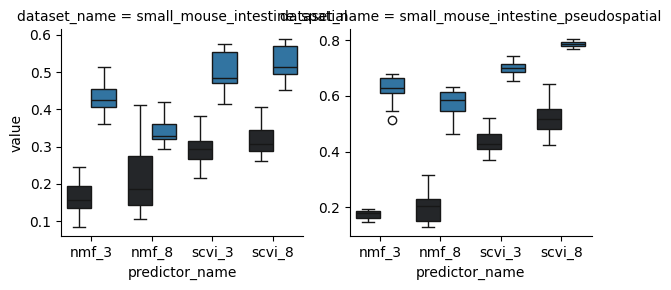

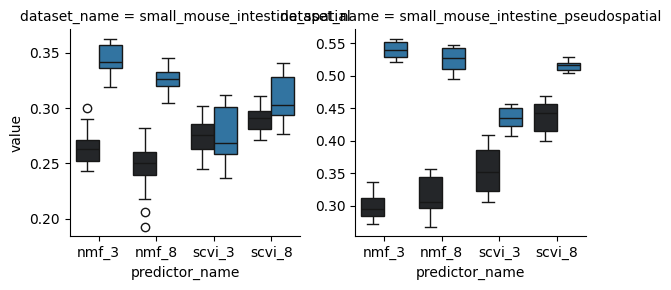

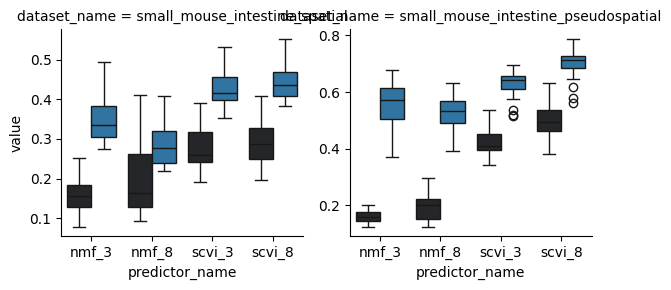

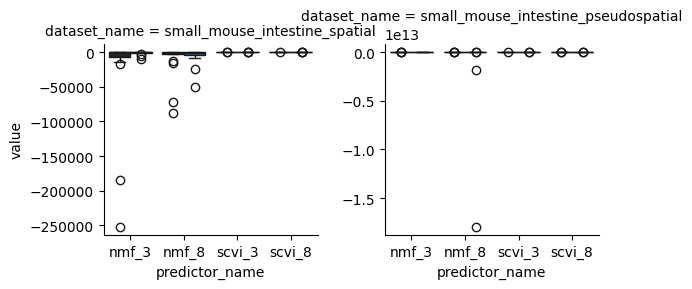

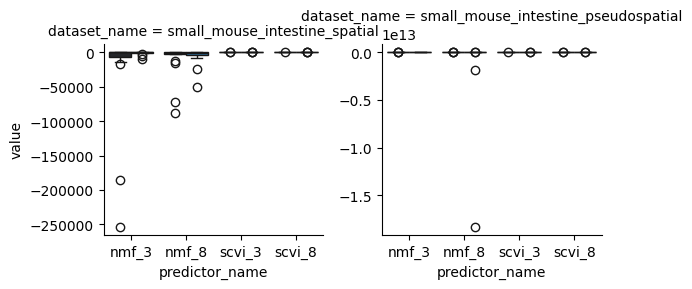

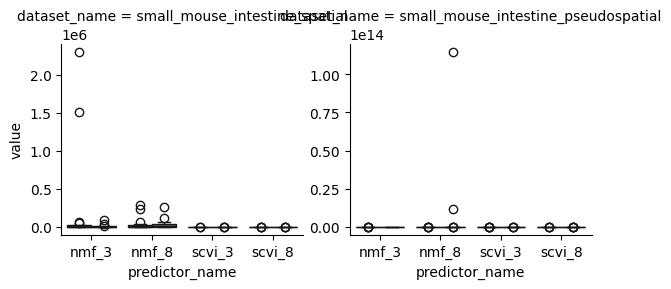

In [ ]:
metrics = ["pearson", "spearman", "cosine", "explaind_var", "explained_var_v2", "mse"]
score_id_cols = [
    "dataset_name",
    "predictor_name",
    "prediction_scope",
    "sample_idx",
    "aggregation_type",
]
for (score_name,), score_df in (
    scores_df.unpivot(
        on=metrics,
        index=score_id_cols,
        variable_name="score_type",
    )
    .partition_by("score_type", as_dict=True)
    .items()
):
    g = sns.FacetGrid(score_df, col="dataset_name", sharey=False, col_wrap=3, aspect=1)

    g.map_dataframe(
        sns.boxplot, x="predictor_name", y="value", hue="prediction_scope", dodge=True
    )
    plt.show()

In [78]:
cluster_frame

run_idx,dataset_name,predictor_name,prediction_scope,sample_idx,block_id,block_celltype,cluster_id,latent_idx,cluster_mean,abs_cluster_mean,n_clusters,n_latent,n_cells_block
i64,str,str,str,i64,str,str,i64,i64,f64,f64,i64,i64,i64
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,0,3.91106,3.91106,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,1,0.048167,0.048167,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,2,3.706549,3.706549,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,1,0,13.35053,13.35053,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,1,1,0.013722,0.013722,3,3,7416
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,3,-3.000968,3.000968,7,8,7
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,4,3.271712,3.271712,7,8,7
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,5,2.981529,2.981529,7,8,7


In [73]:
embedding_pca_components = 25
embedding_random_state = 0


cluster_frame = build_embedding_block_cluster_frame(
    artifact,
    pca_components=embedding_pca_components,
    random_state=embedding_random_state,
)
metrics_df = compute_embedding_block_metrics(cluster_frame)
metrics_df


run_idx,dataset_name,predictor_name,prediction_scope,sample_idx,block_id,block_celltype,n_clusters,n_latent,n_cells_block,normalized_entropy_mean,top1_share_mean,specialization_score,cluster_separation
i64,str,str,str,i64,str,str,i64,i64,i64,f64,f64,f64,f64
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:BZE""","""BZE""",3,3,1153,0.528974,0.713154,0.471026,0.069739
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Blood vasc.""","""Blood vasc.""",3,3,180,0.798845,0.586925,0.201155,0.06353
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Cycling/GC B cell""","""Cycling/GC B cell""",3,3,7,0.014151,0.997334,0.985849,0.000022
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Glial""","""Glial""",3,3,28,2.4820e-12,1.0,1.0,0.0
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Goblet""","""Goblet""",3,3,537,0.636338,0.631237,0.363662,0.094298
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",5,"""global""","""NaN""",8,8,1119,0.915089,0.227238,0.084911,0.282101
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",6,"""global""","""NaN""",8,8,1119,0.909014,0.219562,0.090986,0.273652
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",7,"""global""","""NaN""",8,8,1119,0.92226,0.217377,0.07774,0.292277


In [76]:
cluster_frame

run_idx,dataset_name,predictor_name,prediction_scope,sample_idx,block_id,block_celltype,cluster_id,latent_idx,cluster_mean,abs_cluster_mean,n_clusters,n_latent,n_cells_block
i64,str,str,str,i64,str,str,i64,i64,f64,f64,i64,i64,i64
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,0,3.91106,3.91106,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,1,0.048167,0.048167,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,0,2,3.706549,3.706549,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,1,0,13.35053,13.35053,3,3,7416
0,"""small_mouse_intestine_spatial""","""nmf_3""","""global""",0,"""global""",null,1,1,0.013722,0.013722,3,3,7416
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,3,-3.000968,3.000968,7,8,7
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,4,3.271712,3.271712,7,8,7
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""celltype""",9,"""celltype:pDC""","""pDC""",6,5,2.981529,2.981529,7,8,7


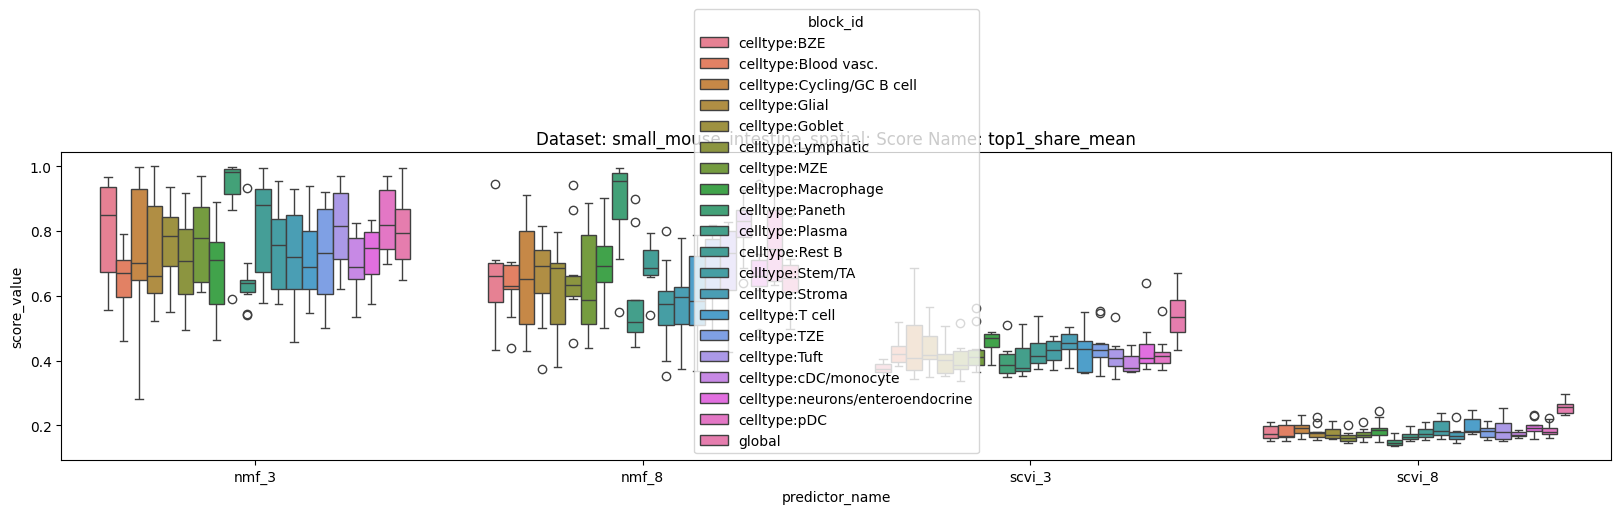

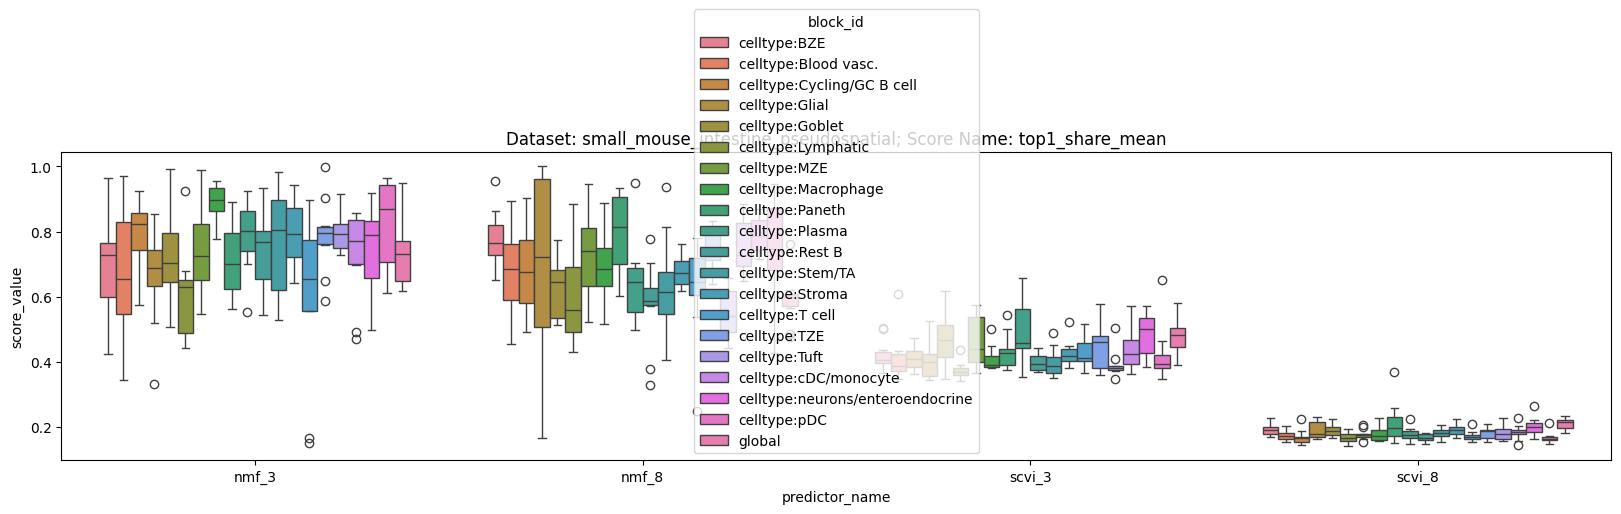

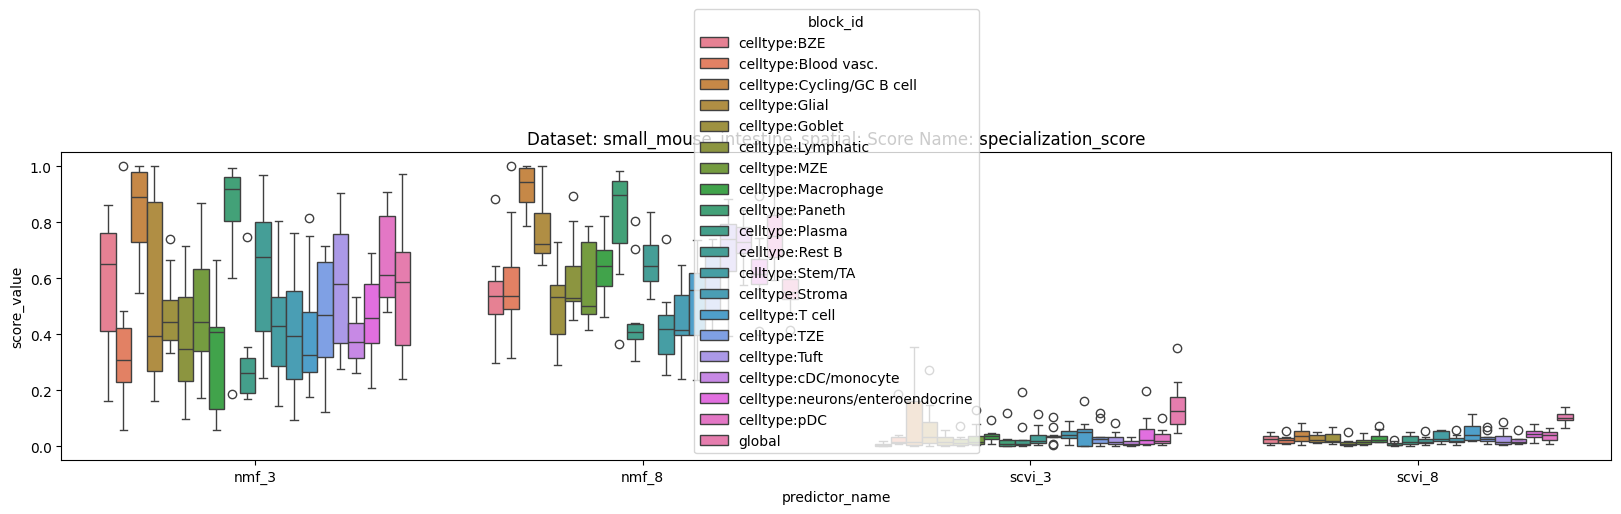

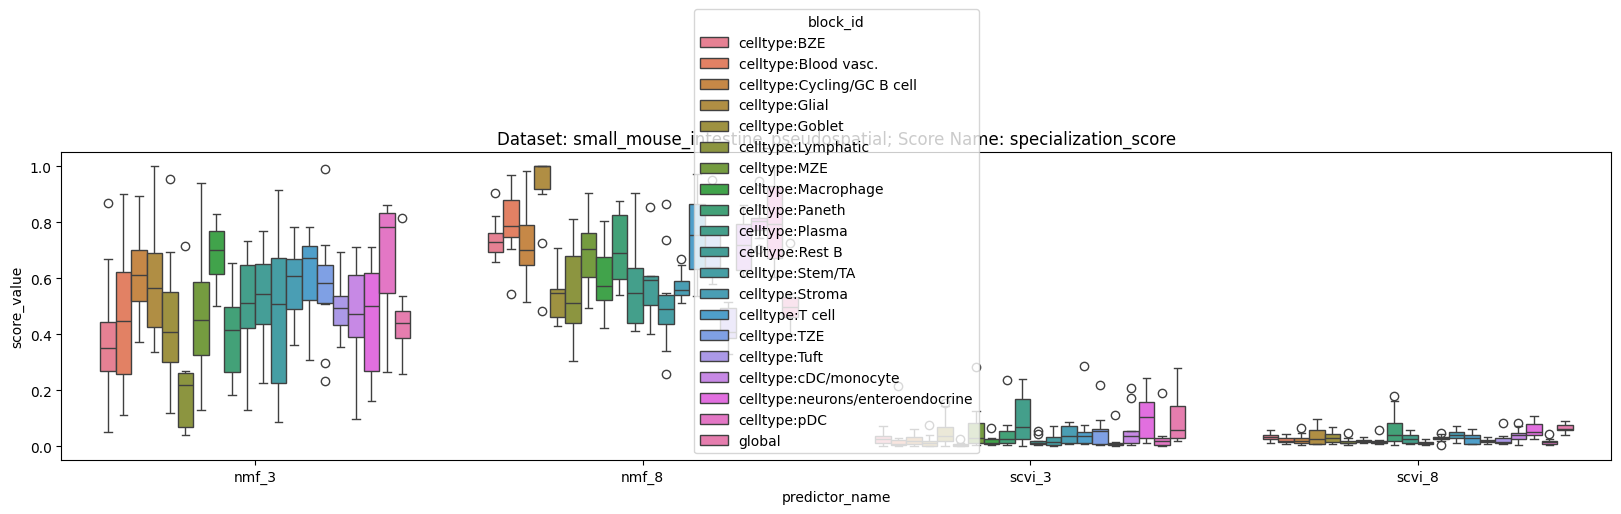

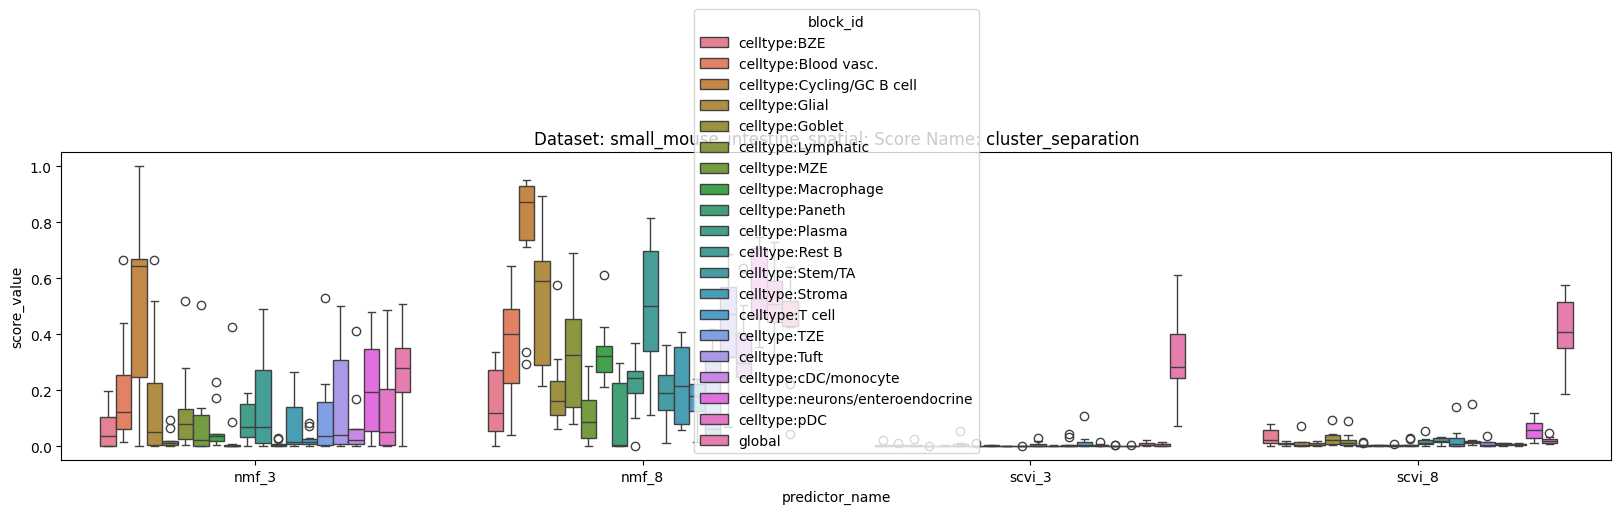

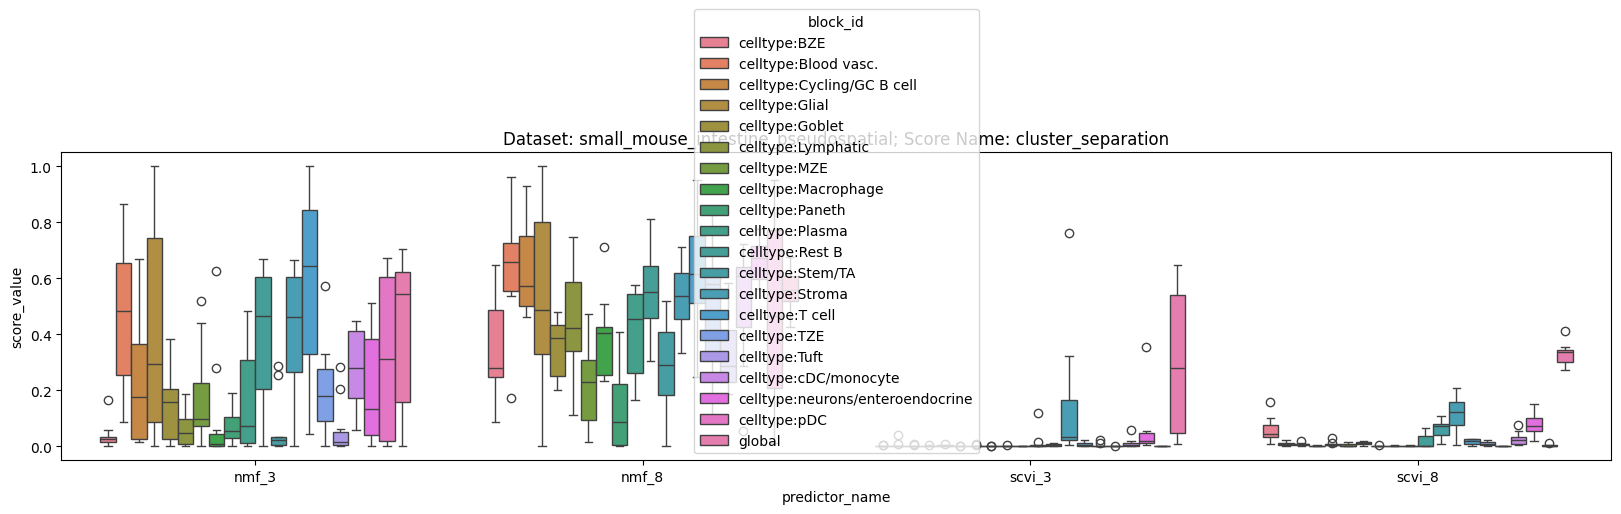

In [ ]:
for key, subdf in (
    metrics_df.unpivot(
        on=[
            "top1_share_mean",
            "specialization_score",
            "cluster_separation",
        ],
        index=[
            "dataset_name",
            "predictor_name",
            "prediction_scope",
            "block_id",
        ],
        variable_name="scoring_type",
        value_name="score_value",
    )
    .partition_by(["dataset_name", "scoring_type"], as_dict=True)
    .items()
):
    plt.figure(figsize=(20, 4))
    sns.boxplot(
        subdf,
        x="predictor_name",
        y="score_value",
        hue="block_id",
    )
    plt.title("Dataset: {}; Score Name: {}".format(*key))
    plt.show()

In [75]:
metrics_df

run_idx,dataset_name,predictor_name,prediction_scope,sample_idx,block_id,block_celltype,n_clusters,n_latent,n_cells_block,normalized_entropy_mean,top1_share_mean,specialization_score,cluster_separation
i64,str,str,str,i64,str,str,i64,i64,i64,f64,f64,f64,f64
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:BZE""","""BZE""",3,3,1153,0.528974,0.713154,0.471026,0.069739
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Blood vasc.""","""Blood vasc.""",3,3,180,0.798845,0.586925,0.201155,0.06353
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Cycling/GC B cell""","""Cycling/GC B cell""",3,3,7,0.014151,0.997334,0.985849,0.000022
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Glial""","""Glial""",3,3,28,2.4820e-12,1.0,1.0,0.0
0,"""small_mouse_intestine_spatial""","""nmf_3""","""celltype""",0,"""celltype:Goblet""","""Goblet""",3,3,537,0.636338,0.631237,0.363662,0.094298
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",5,"""global""","""NaN""",8,8,1119,0.915089,0.227238,0.084911,0.282101
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",6,"""global""","""NaN""",8,8,1119,0.909014,0.219562,0.090986,0.273652
7,"""small_mouse_intestine_pseudosp…","""scvi_8""","""global""",7,"""global""","""NaN""",8,8,1119,0.92226,0.217377,0.07774,0.292277


In [ ]:
embedding_blocks_per_page = 6
embedding_n_cols = 3

detail_group_cols = [
    "run_idx",
    "dataset_name",
    "predictor_name",
    "prediction_scope",
    "sample_idx",
]
detail_figures: list[plt.Figure] = []
detail_grouped = detail_pdf.groupby(detail_group_cols, sort=True, dropna=False)

for detail_group_key, detail_group_df in detail_grouped:
    (
        detail_run_idx,
        detail_dataset,
        detail_predictor,
        detail_scope,
        detail_sample_idx,
    ) = detail_group_key
    detail_block_ids = sorted(detail_group_df["block_id"].drop_duplicates().tolist())
    detail_total_pages = int(np.ceil(len(detail_block_ids) / embedding_blocks_per_page))

    for detail_page_idx, detail_start in enumerate(
        range(0, len(detail_block_ids), embedding_blocks_per_page), start=1
    ):
        detail_page_block_ids = detail_block_ids[
            detail_start : detail_start + embedding_blocks_per_page
        ]
        detail_n_panels = len(detail_page_block_ids)
        detail_n_rows = int(np.ceil(detail_n_panels / embedding_n_cols))

        detail_figure, detail_axes = plt.subplots(
            detail_n_rows,
            embedding_n_cols,
            figsize=(5.0 * embedding_n_cols, 3.8 * detail_n_rows),
            squeeze=False,
        )

        for detail_ax in detail_axes.flat:
            detail_ax.axis("off")

        for detail_panel_idx, detail_block_id in enumerate(detail_page_block_ids):
            detail_ax = detail_axes.flat[detail_panel_idx]
            detail_ax.axis("on")

            detail_block_df = detail_group_df[
                detail_group_df["block_id"] == detail_block_id
            ]
            detail_matrix_df = (
                detail_block_df.pivot_table(
                    index="cluster_id",
                    columns="latent_idx",
                    values="cluster_mean",
                    aggfunc="mean",
                )
                .sort_index(axis=0)
                .sort_index(axis=1)
            )
            detail_matrix = detail_matrix_df.to_numpy(dtype=float)
            detail_z_matrix = _zscore_rows(detail_matrix)
            detail_xticklabels = [
                f"latent_{int(latent)}" for latent in detail_matrix_df.columns
            ]
            detail_yticklabels = [
                f"cluster_{int(cluster)}" for cluster in detail_matrix_df.index
            ]

            sns.heatmap(
                detail_z_matrix,
                cmap="vlag",
                center=0,
                xticklabels=detail_xticklabels,
                yticklabels=detail_yticklabels,
                cbar=False,
                ax=detail_ax,
            )
            detail_ax.set_title(str(detail_block_id), fontsize=10)
            detail_ax.set_xlabel("Latent features")
            detail_ax.set_ylabel("Clusters")
            detail_ax.tick_params(axis="x", rotation=45)

        detail_figure.suptitle(
            f"dataset={detail_dataset} | predictor={detail_predictor} | "
            f"scope={detail_scope} | sample={detail_sample_idx} | run={detail_run_idx} "
            f"| page {detail_page_idx}/{detail_total_pages}",
            y=1.02,
        )
        detail_figure.tight_layout()
        plt.show()
        detail_figures.append(detail_figure)

comparison = {
    "cluster_frame": cluster_frame,
    "metrics_df": metrics_df,
    "summary_metrics_df": summary_metrics_df,
    "summary_figure": summary_figure,
    "detail_figures": detail_figures,
}

In [ ]:
example_run = artifact.runs[0]
umap_dataset_name = str(example_run.run_metadata["dataset_name"])
umap_predictor_name = str(example_run.run_metadata["predictor_name"])
umap_prediction_scope = "global"
umap_sample_idx = 0
umap_pca_components = 25
umap_n_neighbors = 15
umap_min_dist = 0.1
umap_random_state = 0

umap_run = _select_run(
    artifact,
    dataset_name=umap_dataset_name,
    predictor_name=umap_predictor_name,
)
umap_sample = _select_sample(
    umap_run,
    prediction_scope=umap_prediction_scope,
    sample_idx=umap_sample_idx,
)

if umap_prediction_scope == "global":
    umap_blocks_to_plot = [
        block for block in umap_sample.embedding_blocks if block.block_id == "global"
    ]
else:
    umap_blocks_to_plot = list(umap_sample.embedding_blocks)

umap_query_counts = np.asarray(umap_run.shared.query_counts)
factor_umap_figures: list[plt.Figure] = []

for umap_block in umap_blocks_to_plot:
    umap_row_indices = np.asarray(umap_block.row_indices, dtype=np.int_)
    umap_embedding_values = np.asarray(umap_block.values, dtype=float)
    umap_query_counts_block = np.asarray(
        umap_query_counts[umap_row_indices], dtype=float
    )

    umap_n_cells, umap_n_genes = umap_query_counts_block.shape
    umap_pca_n = min(umap_pca_components, umap_n_cells - 1, umap_n_genes)

    umap_scaled_query_counts = _zscore_cols(umap_query_counts_block)
    umap_pca_embedding = PCA(n_components=umap_pca_n).fit_transform(
        umap_scaled_query_counts
    )
    umap_n_neighbors_effective = min(umap_n_neighbors, umap_n_cells - 1)
    umap_embedding_2d = UMAP(
        n_components=2,
        n_neighbors=umap_n_neighbors_effective,
        min_dist=umap_min_dist,
        random_state=umap_random_state,
    ).fit_transform(umap_pca_embedding)

    umap_n_factors = int(umap_embedding_values.shape[1])
    umap_n_rows, umap_n_cols = _factor_subplot_shape(umap_n_factors)
    factor_umap_figure, factor_umap_axes = plt.subplots(
        umap_n_rows,
        umap_n_cols,
        figsize=(5.0 * umap_n_cols, 4.0 * umap_n_rows),
        squeeze=False,
    )

    for factor_idx, factor_ax in enumerate(factor_umap_axes.flat):
        if factor_idx >= umap_n_factors:
            factor_ax.axis("off")
            continue

        factor_scatter = factor_ax.scatter(
            umap_embedding_2d[:, 0],
            umap_embedding_2d[:, 1],
            c=umap_embedding_values[:, factor_idx],
            cmap="viridis",
            s=18,
            alpha=0.9,
            linewidths=0,
        )
        factor_ax.set_title(f"factor_{factor_idx}")
        factor_ax.set_xlabel("UMAP1")
        factor_ax.set_ylabel("UMAP2")
        factor_umap_figure.colorbar(
            factor_scatter,
            ax=factor_ax,
            fraction=0.046,
            pad=0.04,
        )

    umap_block_label = (
        umap_block.celltype if umap_block.celltype is not None else umap_block.block_id
    )
    factor_umap_figure.suptitle(
        f"dataset={umap_dataset_name} | predictor={umap_predictor_name} | "
        f"scope={umap_prediction_scope} | sample={umap_sample_idx} | "
        f"block={umap_block_label}",
        y=1.02,
    )
    factor_umap_figure.tight_layout()
    plt.show()
    factor_umap_figures.append(factor_umap_figure)
